In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub


In [3]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

print("Experiment: ResNet50 Balanced Batches + Focal Loss")
print("Focal gamma: 2.0")
print("Focal alpha balancing: Disabled")
print("Dropout: Disabled")
print("Class weights: Disabled")

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Experiment: ResNet50 Balanced Batches + Focal Loss
Focal gamma: 2.0
Focal alpha balancing: Disabled
Dropout: Disabled
Class weights: Disabled


In [4]:
dataset_path = kagglehub.dataset_download(
    "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
)

image_root = Path(dataset_path) / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Mounting files to /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented...
Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [5]:
class_mapping = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_mapping.items():
    class_folder = image_root / class_name

    for file_path in sorted(class_folder.iterdir()):
        if file_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(file_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))

print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["label"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df), "images")
print(train_df["label"].value_counts().sort_index())

print("\nValidation:", len(validation_df), "images")
print(validation_df["label"].value_counts().sort_index())

print("\nTesting:", len(test_df), "images")
print(test_df["label"].value_counts().sort_index())

Training: 30800 images
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
HALF_BATCH = BATCH_SIZE // 2
AUTOTUNE = tf.data.AUTOTUNE

def load_original_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, tf.cast(label, tf.float32)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Images from each class per training batch:", HALF_BATCH)

Image size: (224, 224)
Batch size: 32
Images from each class per training batch: 16


In [8]:
class_0_df = train_df[train_df["label"] == 0]
class_1_df = train_df[train_df["label"] == 1]

def create_repeated_class_dataset(dataframe):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].values,
        dataframe["label"].values
    ))

    dataset = dataset.shuffle(
        buffer_size=len(dataframe),
        seed=SEED,
        reshuffle_each_iteration=True
    )

    dataset = dataset.repeat()
    dataset = dataset.map(
        load_original_image,
        num_parallel_calls=AUTOTUNE
    )

    return dataset.batch(
        HALF_BATCH,
        drop_remainder=True
    )

class_0_dataset = create_repeated_class_dataset(class_0_df)
class_1_dataset = create_repeated_class_dataset(class_1_df)

def merge_balanced_batches(class_0_batch, class_1_batch):
    images = tf.concat(
        [class_0_batch[0], class_1_batch[0]],
        axis=0
    )
    labels = tf.concat(
        [class_0_batch[1], class_1_batch[1]],
        axis=0
    )

    shuffled_indices = tf.random.shuffle(
        tf.range(BATCH_SIZE)
    )

    return (
        tf.gather(images, shuffled_indices),
        tf.gather(labels, shuffled_indices)
    )

balanced_train_dataset = tf.data.Dataset.zip((
    class_0_dataset,
    class_1_dataset
)).map(
    merge_balanced_batches,
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

def create_evaluation_dataset(dataframe):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].values,
        dataframe["label"].values
    ))

    return dataset.map(
        load_original_image,
        num_parallel_calls=AUTOTUNE
    ).batch(BATCH_SIZE).prefetch(AUTOTUNE)

validation_dataset = create_evaluation_dataset(validation_df)
test_dataset = create_evaluation_dataset(test_df)

STEPS_PER_EPOCH = int(np.ceil(len(train_df) / BATCH_SIZE))

print("Class 0 training images:", len(class_0_df))
print("Class 1 training images:", len(class_1_df))
print("Steps per epoch:", STEPS_PER_EPOCH)

I0000 00:00:1789376431.541821      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Class 0 training images: 8960
Class 1 training images: 21840
Steps per epoch: 963


In [9]:
image_batch, label_batch = next(
    iter(balanced_train_dataset)
)

print("Image batch shape:", image_batch.shape)
print("Label batch shape:", label_batch.shape)

print(
    "Pixel range:",
    float(tf.reduce_min(image_batch)),
    "to",
    float(tf.reduce_max(image_batch))
)

print(
    "NonDemented in batch:",
    int(tf.reduce_sum(
        tf.cast(label_batch == 0, tf.int32)
    ))
)

print(
    "Demented in batch:",
    int(tf.reduce_sum(
        tf.cast(label_batch == 1, tf.int32)
    ))
)

print("First labels:", label_batch[:10].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0
NonDemented in batch: 16
Demented in batch: 16
First labels: [1. 1. 1. 1. 0. 0. 1. 0. 1. 0.]


In [10]:
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001
FOCAL_GAMMA = 2.0

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Steps per epoch:", STEPS_PER_EPOCH)
print("Focal gamma:", FOCAL_GAMMA)

print("Preprocessing: Original images")
print("Data augmentation: Disabled")
print("Dropout rate: Disabled")
print("Balanced batches: Enabled")
print("Focal alpha balancing: Disabled")
print("Class weights: Disabled")

Image size: (224, 224)
Batch size: 32
Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001
Steps per epoch: 963
Focal gamma: 2.0
Preprocessing: Original images
Data augmentation: Disabled
Dropout rate: Disabled
Balanced batches: Enabled
Focal alpha balancing: Disabled
Class weights: Disabled


In [11]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))

x = tf.keras.applications.resnet50.preprocess_input(inputs)

base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Dropout intentionally removed
outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="ResNet50_Balanced_Focal_NoDropout"
)

focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
    apply_class_balancing=False,
    gamma=FOCAL_GAMMA,
    from_logits=False
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=focal_loss,
    metrics=["accuracy"]
)

print("Total parameters:", model.count_params())
print(
    "Trainable parameters:",
    sum(tf.keras.backend.count_params(weight)
        for weight in model.trainable_weights)
)
print("ResNet50 frozen:", not base_model.trainable)
print("Dropout enabled: False")
print("Balanced batches: True")
print("Focal alpha balancing: False")
print("Focal gamma:", FOCAL_GAMMA)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Total parameters: 23589761
Trainable parameters: 2049
ResNet50 frozen: True
Dropout enabled: False
Balanced batches: True
Focal alpha balancing: False
Focal gamma: 2.0


Model: "ResNet50_Balanced_Focal_NoDropout"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/resnet50_balanced_focal_no_dropout_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks created.")

Callbacks created.


In [13]:
history = model.fit(
    balanced_train_dataset,
    validation_data=validation_dataset,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
  4/963 ━━━━━━━━━━━━━━━━━━━━ 46s 48ms/step - accuracy: 0.4980 - loss: 0.4535 

I0000 00:00:1789376625.281165     142 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


962/963 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6109 - loss: 0.1821
Epoch 1: val_loss improved from None to 0.13327, saving model to /kaggle/working/resnet50_balanced_focal_no_dropout_best.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_balanced_focal_no_dropout_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 88s 78ms/step - accuracy: 0.6935 - loss: 0.1507 - val_accuracy: 0.7476 - val_loss: 0.1333 - learning_rate: 1.0000e-04
Epoch 2/30
962/963 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7722 - loss: 0.1217
Epoch 2: val_loss improved from 0.13327 to 0.11613, saving model to /kaggle/working/resnet50_balanced_focal_no_dropout_best.keras

Epoch 2: finished saving model to /kaggle/working/resnet50_balanced_focal_no_dropout_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 57s 59ms/step - accuracy: 0.7740 - loss: 0.1204 - val_accuracy: 0.7870 - val_loss: 0.1161 - learning_rate: 1.0000e-04
Epoch 3/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7816 - loss: 0.1155
Epoch

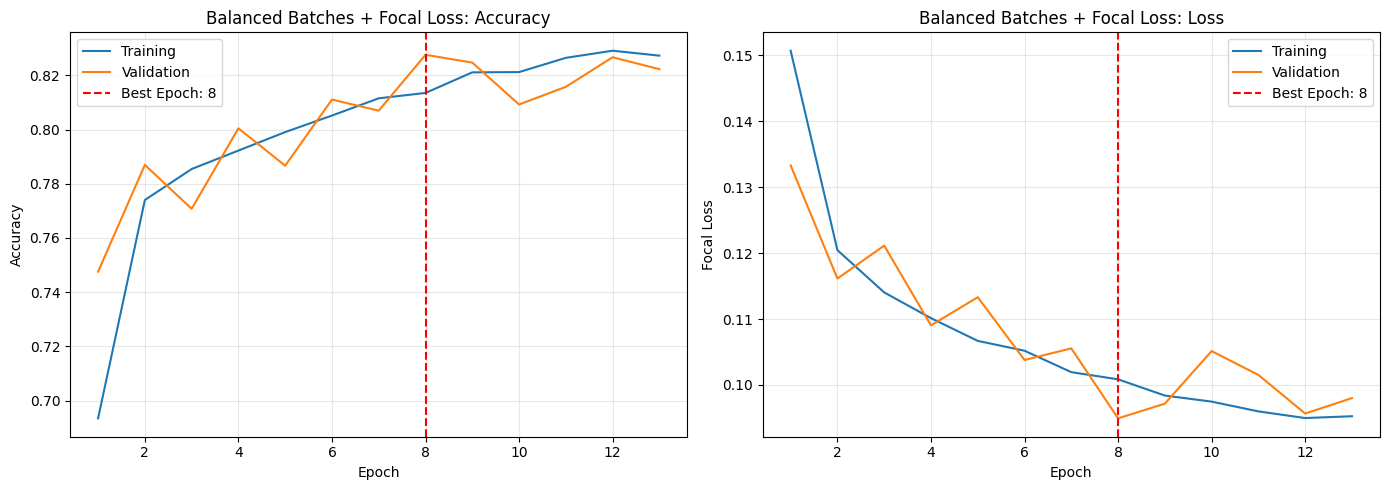

In [14]:
best_epoch = np.argmin(history.history["val_loss"]) + 1
epochs = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history.history["accuracy"], label="Training")
axes[0].plot(epochs, history.history["val_accuracy"], label="Validation")
axes[0].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[0].set_title("Balanced Batches + Focal Loss: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history.history["loss"], label="Training")
axes[1].plot(epochs, history.history["val_loss"], label="Validation")
axes[1].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[1].set_title("Balanced Batches + Focal Loss: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Focal Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
best_model = tf.keras.models.load_model(
    "/kaggle/working/resnet50_balanced_focal_no_dropout_best.keras"
)

print("Best balanced-batch focal model loaded.")
print("Selected validation-loss epoch:", best_epoch)

Best balanced-batch focal model loaded.
Selected validation-loss epoch: 8


In [16]:
test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("Test Focal Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

207/207 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8276 - loss: 0.0966
Test Focal Loss: 0.0966
Test Accuracy: 0.8276


In [17]:
test_probabilities = best_model.predict(
    test_dataset,
    verbose=1
).ravel()

test_predictions = (test_probabilities >= 0.5).astype(int)
true_labels = test_df["label"].to_numpy()

print("Test images:", len(true_labels))
print("Probabilities:", len(test_probabilities))
print("Predictions:", len(test_predictions))
print("First probabilities:", np.round(test_probabilities[:10], 4))
print("First predictions:", test_predictions[:10])

207/207 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step
Test images: 6600
Probabilities: 6600
Predictions: 6600
First probabilities: [0.7199 0.7146 0.6217 0.5765 0.7196 0.7158 0.6769 0.554  0.8609 0.7099]
First predictions: [1 1 1 1 1 1 1 1 1 1]


In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

tn, fp, fn, tp = confusion_matrix(
    true_labels, test_predictions
).ravel()

specificity = tn / (tn + fp)

print("Test Focal Loss:", round(test_loss, 4))
print("Accuracy:", round(
    accuracy_score(true_labels, test_predictions), 4
))
print("Balanced Accuracy:", round(
    balanced_accuracy_score(true_labels, test_predictions), 4
))
print("Precision:", round(
    precision_score(true_labels, test_predictions), 4
))
print("Recall/Sensitivity:", round(
    recall_score(true_labels, test_predictions), 4
))
print("Specificity:", round(specificity, 4))
print("F1-score:", round(
    f1_score(true_labels, test_predictions), 4
))
print("ROC-AUC:", round(
    roc_auc_score(true_labels, test_probabilities), 4
))
print("PR-AUC:", round(
    average_precision_score(true_labels, test_probabilities), 4
))

Test Focal Loss: 0.0966
Accuracy: 0.8276
Balanced Accuracy: 0.8073
Precision: 0.8964
Recall/Sensitivity: 0.8558
Specificity: 0.7589
F1-score: 0.8756
ROC-AUC: 0.9009
PR-AUC: 0.9561


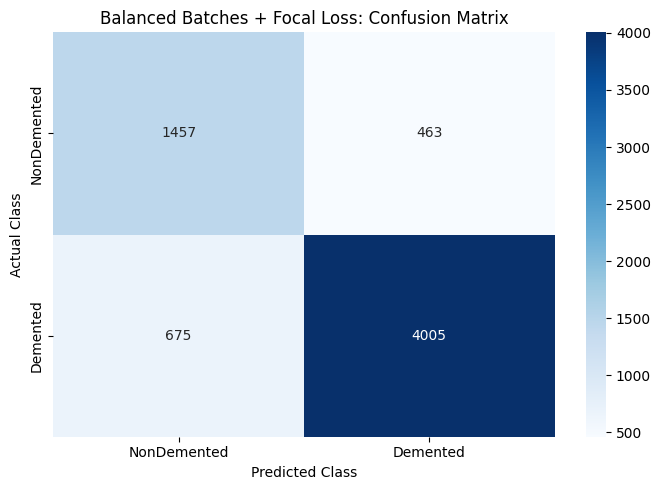

In [19]:
cm = confusion_matrix(true_labels, test_predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"]
)

plt.title("Balanced Batches + Focal Loss: Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        test_predictions,
        target_names=["NonDemented", "Demented"],
        digits=4
    )
)

              precision    recall  f1-score   support

 NonDemented     0.6834    0.7589    0.7192      1920
    Demented     0.8964    0.8558    0.8756      4680

    accuracy                         0.8276      6600
   macro avg     0.7899    0.8073    0.7974      6600
weighted avg     0.8344    0.8276    0.8301      6600



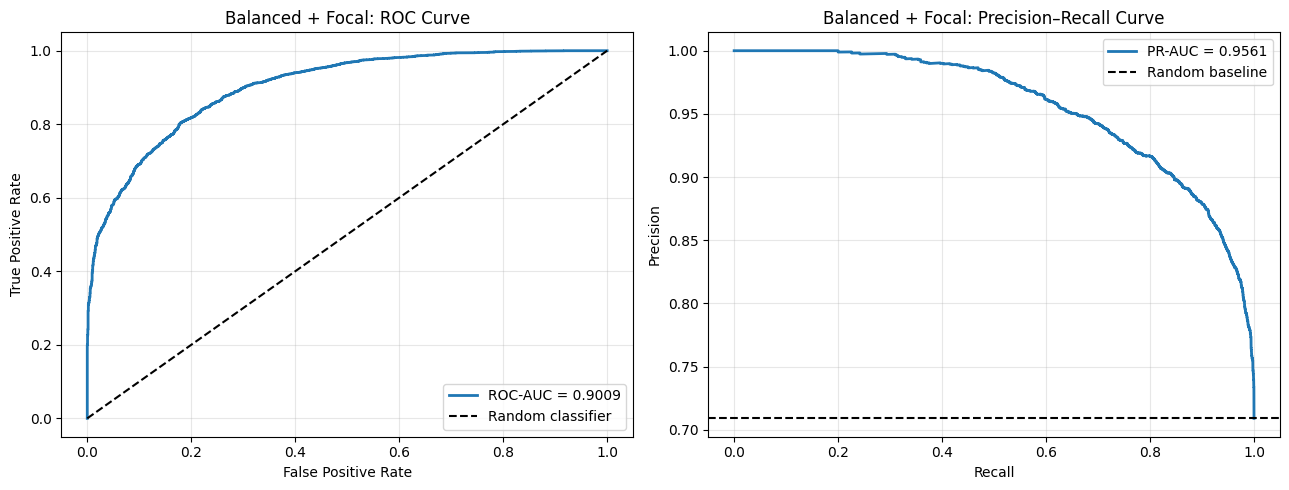

In [22]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(true_labels, test_probabilities)
pr_precision, pr_recall, _ = precision_recall_curve(
    true_labels, test_probabilities
)

roc_auc = roc_auc_score(true_labels, test_probabilities)
pr_auc = average_precision_score(true_labels, test_probabilities)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    fpr, tpr,
    linewidth=2,
    label=f"ROC-AUC = {roc_auc:.4f}"
)
axes[0].plot([0, 1], [0, 1], "k--", label="Random classifier")
axes[0].set_title("Balanced + Focal: ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    pr_recall, pr_precision,
    linewidth=2,
    label=f"PR-AUC = {pr_auc:.4f}"
)
axes[1].axhline(
    true_labels.mean(),
    color="black",
    linestyle="--",
    label="Random baseline"
)
axes[1].set_title("Balanced + Focal: Precision–Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
results = pd.DataFrame([{
    "Experiment": "ResNet50 Balanced Batches Focal No Dropout",
    "Focal Gamma": FOCAL_GAMMA,
    "Focal Alpha Balancing": False,
    "Test Focal Loss": test_loss,
    "Accuracy": accuracy_score(true_labels, test_predictions),
    "Balanced Accuracy": balanced_accuracy_score(
        true_labels, test_predictions
    ),
    "Precision": precision_score(true_labels, test_predictions),
    "Recall": recall_score(true_labels, test_predictions),
    "Specificity": specificity,
    "F1-score": f1_score(true_labels, test_predictions),
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}])

results.to_csv(
    "/kaggle/working/resnet50_balanced_focal_no_dropout_results.csv",
    index=False
)

pd.DataFrame(history.history).to_csv(
    "/kaggle/working/resnet50_balanced_focal_no_dropout_history.csv",
    index=False
)

prediction_results = test_df.copy()
prediction_results["probability"] = test_probabilities
prediction_results["prediction"] = test_predictions
prediction_results.to_csv(
    "/kaggle/working/resnet50_balanced_focal_no_dropout_predictions.csv",
    index=False
)

display(results)
print("All combined experiment files saved.")

,Experiment,Focal Gamma,Focal Alpha Balancing,Test Focal Loss,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,PR-AUC
0,ResNet50 Balanced Batches Focal No Dropout,2.0,False,0.096556,0.827576,0.807312,0.896374,0.855769,0.758854,0.875601,0.900936,0.95615


All combined experiment files saved.
